In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
IMAGE_DIR = "../data/images"
MASK_DIR = "../data/masks"

IMG_SIZE = 256
RANDOM_STATE = 42

In [14]:
image_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

mask_files = sorted([
    f for f in os.listdir(MASK_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Number of images:", len(image_files))
print("Number of masks:", len(mask_files))

Number of images: 900
Number of masks: 900


In [15]:
def get_image_id(filename):
    """
    Extract the common ISIC ID from an image or mask filename.
    Example:
        ISIC_0000000.jpg
        ISIC_0000000_Segmentation.png
    both become:
        ISIC_0000000
    """
    
    stem = os.path.splitext(filename)[0]
    
    # Remove the segmentation suffix from mask filenames
    stem = stem.replace("_Segmentation", "")
    
    return stem


image_ids = {
    get_image_id(f)
    for f in image_files
}

mask_ids = {
    get_image_id(f)
    for f in mask_files
}


missing_masks = image_ids - mask_ids
missing_images = mask_ids - image_ids


print("Images:", len(image_ids))
print("Masks:", len(mask_ids))

print("Images without masks:", len(missing_masks))
print("Masks without images:", len(missing_images))


if missing_masks:
    print("\nMissing masks:")
    print(sorted(missing_masks))

if missing_images:
    print("\nMissing images:")
    print(sorted(missing_images))

Images: 900
Masks: 900
Images without masks: 0
Masks without images: 0


In [16]:
# Create a dictionary of masks using the common ISIC ID

mask_dict = {
    get_image_id(filename): filename
    for filename in mask_files
}


image_mask_pairs = []

for image_file in image_files:

    image_id = get_image_id(image_file)

    if image_id in mask_dict:

        mask_file = mask_dict[image_id]

        image_mask_pairs.append(
            (image_file, mask_file)
        )


print("Total image-mask pairs:", len(image_mask_pairs))

Total image-mask pairs: 900


In [19]:
# checking few pairs
for image_file, mask_file in image_mask_pairs[:10]:
    print(f"{image_file}  -->  {mask_file}")

ISIC_0000000.jpg  -->  ISIC_0000000_Segmentation.png
ISIC_0000001.jpg  -->  ISIC_0000001_Segmentation.png
ISIC_0000002.jpg  -->  ISIC_0000002_Segmentation.png
ISIC_0000004.jpg  -->  ISIC_0000004_Segmentation.png
ISIC_0000006.jpg  -->  ISIC_0000006_Segmentation.png
ISIC_0000007.jpg  -->  ISIC_0000007_Segmentation.png
ISIC_0000008.jpg  -->  ISIC_0000008_Segmentation.png
ISIC_0000009.jpg  -->  ISIC_0000009_Segmentation.png
ISIC_0000010.jpg  -->  ISIC_0000010_Segmentation.png
ISIC_0000011.jpg  -->  ISIC_0000011_Segmentation.png


In [17]:
sample_image = cv2.imread(
    os.path.join(IMAGE_DIR, image_files[0])
)

sample_mask = cv2.imread(
    os.path.join(MASK_DIR, mask_files[0]),
    cv2.IMREAD_GRAYSCALE
)

print("Sample image shape:", sample_image.shape)
print("Sample mask shape:", sample_mask.shape)

Sample image shape: (767, 1022, 3)
Sample mask shape: (767, 1022)


In [18]:
unique_values = np.unique(sample_mask)

print("Unique mask values:", unique_values)

Unique mask values: [  0 255]


In [20]:
all_mask_values = set()

for filename in mask_files:
    mask = cv2.imread(
        os.path.join(MASK_DIR, filename),
        cv2.IMREAD_GRAYSCALE
    )

    all_mask_values.update(np.unique(mask))

print("All unique mask values found:", sorted(all_mask_values))

All unique mask values found: [0, 255]


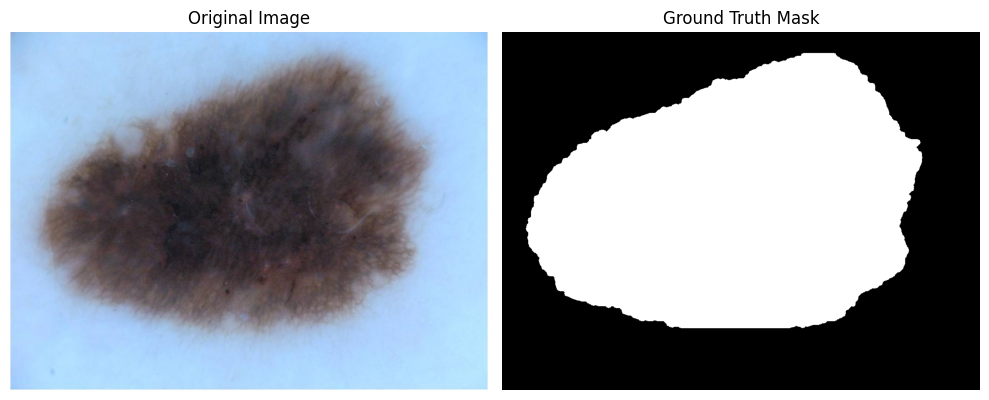

In [21]:
image = cv2.imread(
    os.path.join(IMAGE_DIR, image_files[0])
)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread(
    os.path.join(MASK_DIR, mask_files[0]),
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

## Preprocessing

In [9]:
def preprocess_image_and_mask(image_path, mask_path, img_size=256):

    # Read image
    image = cv2.imread(image_path)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read mask as grayscale
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize image
    image = cv2.resize(
        image,
        (img_size, img_size),
        interpolation=cv2.INTER_AREA
    )

    # Resize mask
    mask = cv2.resize(
        mask,
        (img_size, img_size),
        interpolation=cv2.INTER_NEAREST
    )

    # Normalize image to [0, 1]
    image = image.astype(np.float32) / 255.0

    # Convert mask to binary {0, 1}
    mask = (mask > 0).astype(np.float32)

    # Add channel dimension to mask
    mask = np.expand_dims(mask, axis=-1)

    return image, mask

In [ ]:
# test preprocesing function

image_path = os.path.join(IMAGE_DIR, image_files[0])
mask_path = os.path.join(MASK_DIR, mask_files[0])

processed_image, processed_mask = preprocess_image_and_mask(
    image_path,
    mask_path,
    IMG_SIZE
)

print("Processed image shape:", processed_image.shape)
print("Processed image dtype:", processed_image.dtype)
print("Image min:", processed_image.min())
print("Image max:", processed_image.max())

print()

print("Processed mask shape:", processed_mask.shape)
print("Processed mask dtype:", processed_mask.dtype)
print("Unique mask values:", np.unique(processed_mask))

Processed image shape: (256, 256, 3)
Processed image dtype: float32
Image min: 0.047058824
Image max: 0.93333334

Processed mask shape: (256, 256, 1)
Processed mask dtype: float32
Unique mask values: [0. 1.]


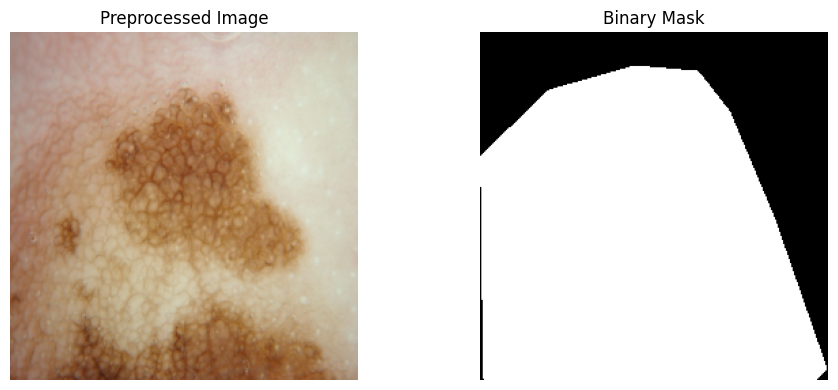

In [25]:
# visualize preprocessed image and mask
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(processed_image)
plt.title("Preprocessed Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_mask.squeeze(), cmap="gray")
plt.title("Binary Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
images = []
masks = []

for image_file, mask_file in image_mask_pairs:

    image_path = os.path.join(IMAGE_DIR, image_file)
    mask_path = os.path.join(MASK_DIR, mask_file)

    image, mask = preprocess_image_and_mask(
        image_path,
        mask_path,
        IMG_SIZE
    )

    images.append(image)
    masks.append(mask)

print("Number of processed images:", len(images))
print("Number of processed masks:", len(masks))

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Number of processed images: 900
Number of processed masks: 900
Images shape: (900, 256, 256, 3)
Masks shape: (900, 256, 256, 1)


In [28]:
print("Images:")
print("Shape:", images.shape)
print("Dtype:", images.dtype)
print("Min:", images.min())
print("Max:", images.max())

print("\nMasks:")
print("Shape:", masks.shape)
print("Dtype:", masks.dtype)
print("Unique values:", np.unique(masks))

Images:
Shape: (900, 256, 256, 3)
Dtype: float32
Min: 0.0
Max: 1.0

Masks:
Shape: (900, 256, 256, 1)
Dtype: float32
Unique values: [0. 1.]


In [29]:
X_train, X_temp, Y_train, Y_temp = train_test_split(
    images,
    masks,
    test_size=0.20,
    random_state=RANDOM_STATE
)

In [30]:
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

In [31]:
print("Training:")
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

print("\nTest:")
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

Training:
X_train: (720, 256, 256, 3)
Y_train: (720, 256, 256, 1)

Validation:
X_val: (90, 256, 256, 3)
Y_val: (90, 256, 256, 1)

Test:
X_test: (90, 256, 256, 3)
Y_test: (90, 256, 256, 1)


In [32]:
np.save("../data/X_train.npy", X_train)
np.save("../data/Y_train.npy", Y_train)

np.save("../data/X_val.npy", X_val)
np.save("../data/Y_val.npy", Y_val)

np.save("../data/X_test.npy", X_test)
np.save("../data/Y_test.npy", Y_test)

print("Preprocessed datasets saved successfully.")

Preprocessed datasets saved successfully.


In [33]:
X_train_loaded = np.load("../data/X_train.npy")
Y_train_loaded = np.load("../data/Y_train.npy")

X_val_loaded = np.load("../data/X_val.npy")
Y_val_loaded = np.load("../data/Y_val.npy")

X_test_loaded = np.load("../data/X_test.npy")
Y_test_loaded = np.load("../data/Y_test.npy")

print("X_train:", X_train_loaded.shape)
print("Y_train:", Y_train_loaded.shape)

print("X_val:", X_val_loaded.shape)
print("Y_val:", Y_val_loaded.shape)

print("X_test:", X_test_loaded.shape)
print("Y_test:", Y_test_loaded.shape)

X_train: (720, 256, 256, 3)
Y_train: (720, 256, 256, 1)
X_val: (90, 256, 256, 3)
Y_val: (90, 256, 256, 1)
X_test: (90, 256, 256, 3)
Y_test: (90, 256, 256, 1)


In [34]:
#final check
assert X_train.shape == (720, 256, 256, 3)
assert Y_train.shape == (720, 256, 256, 1)

assert X_val.shape == (90, 256, 256, 3)
assert Y_val.shape == (90, 256, 256, 1)

assert X_test.shape == (90, 256, 256, 3)
assert Y_test.shape == (90, 256, 256, 1)

assert X_train.dtype == np.float32
assert Y_train.dtype == np.float32

assert X_train.min() >= 0.0
assert X_train.max() <= 1.0

assert set(np.unique(Y_train)).issubset({0.0, 1.0})
assert set(np.unique(Y_val)).issubset({0.0, 1.0})
assert set(np.unique(Y_test)).issubset({0.0, 1.0})

print("All preprocessing checks passed.")

All preprocessing checks passed.
